# Explorador de gráficos — despidos tech 2026

Notebook para iterar gráficos con el **mismo tema y la misma data** que el sitio.
Reusa `charts.py`: el tema "Lenny", los helpers y los **161 eventos** ya filtrados a ene–jun 2026.

- `df` → la data como DataFrame de pandas (para filtrar / agrupar).
- `new_chart()` → un `fig, ax` con el tema ya aplicado.
- `save_chart(fig, "nombre")` → guarda en `charts/nombre.png` (mismo estilo que los publicados).

Corre las celdas de arriba hacia abajo; la de **Setup** siempre primero.

In [1]:
# --- Setup (correr siempre) ---
%matplotlib inline
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

import charts  # tema Lenny + data (161 eventos in-window) + helpers
from charts import (LENNY, apply_lenny_theme, add_lenny_header, fmt_int, CHARTS)

df = pd.DataFrame(charts.data)
df['laid_off'] = pd.to_numeric(df['laid_off'], errors='coerce')
C = LENNY  # paleta: C['accent'], C['accent_deep'], C['ser_secondary'], C['ser_muted']...

def new_chart(figsize=(11, 6.5)):
    """Devuelve (fig, ax) con el tema del sitio ya aplicado."""
    fig, ax = plt.subplots(figsize=figsize)
    apply_lenny_theme(fig, ax)
    return fig, ax

def source(fig, text):
    """'Datos de: <text>' abajo-izquierda + 'trabajoremoto.cl' abajo-derecha, mismo color."""
    col = LENNY['subtitle']
    fig.text(0.02, 0.03, "Datos de: " + text, fontsize=10, color=col)
    fig.text(0.985, 0.03, "trabajoremoto.cl", fontsize=10, ha='right', color=col)

def save_chart(fig, name):
    """Guarda en charts/<name>.png con el fondo y dpi del sitio."""
    out = CHARTS / f"{name}.png"
    fig.savefig(out, facecolor=LENNY['bg'], dpi=160)
    print("guardado:", out); return out

print(f"{len(df)} eventos · {int(df['laid_off'].sum()):,} personas con cifra")
df.head(3)

161 eventos · 108,089 personas con cifra


,company,date,laid_off,pct,industry,stage,country,location_hq,source_url,reason,...,story_integrity,narrative_source,ai_position,profiles_cut,profiles_hired,hire_overcorrection,reassignment_observed,causes,cause_evidence,ai_claim_verdict
0,Multiverse,2026-01-05,55.0,NaN,Education,Series D,United Kingdom,"[London, Non-U.S.]",https://sifted.eu/articles/multiverse-job-cuts...,Strategy to employ slightly fewer people while...,...,None,news_inferred,n/a,[],[],None,None,[cost_cutting],{'cost_cutting': ''revenue per employee' targe...,not_claimed
1,Angi,2026-01-07,350.0,NaN,Consumer,Post-IPO,United States,[Indianapolis],https://ir.angi.com/node/12951/html,Angi announced ~350 layoffs to 'reduce operati...,...,None,news_inferred,token_buyer,[],[],None,None,[ai_substitution_claim],{'ai_substitution_claim': 'ai_link=direct_subs...,thin_evidence
2,Foretellix,2026-01-08,29.0,0.18,Transportation,Series C,Israel,"[Tel Aviv, Non-U.S.]",https://www.calcalistech.com/ctechnews/article...,Efficiency measures driven in part by the grow...,...,None,news_inferred,infra_seller,[],[],None,None,"[ai_press_narrative, restructuring_unspecified]",{'ai_press_narrative': 'ai_link=ai_narrative_o...,not_claimed


## Exploración rápida

`df` tiene una fila por evento. Columnas clave: `ai_link` (mecanismo), `ai_link_basis` (quién lo dijo),
`hire_overcorrection`, `story_integrity`, `ai_position`, `reason_primary`. Detalle en `schema.md`.

In [2]:
# ¿de dónde vienen las personas despedidas? (por mecanismo frente a la IA)
g = df.groupby('ai_link').agg(eventos=('company', 'size'),
                              personas=('laid_off', 'sum'))
g['%'] = (100 * g['personas'] / df['laid_off'].sum()).round(1)
g.sort_values('personas', ascending=False)

,eventos,personas,%
ai_link,,,
direct_substitution,31,38899.0,36.0
unrelated,93,28717.0,26.6
ai_narrative_only,31,25223.0,23.3
capex_funding,6,15250.0,14.1


## Un gráfico con el tema del sitio

Ejemplo: top 10 despidos por número de personas. Cámbialo a gusto (otra columna, otro `groupby`, etc.).

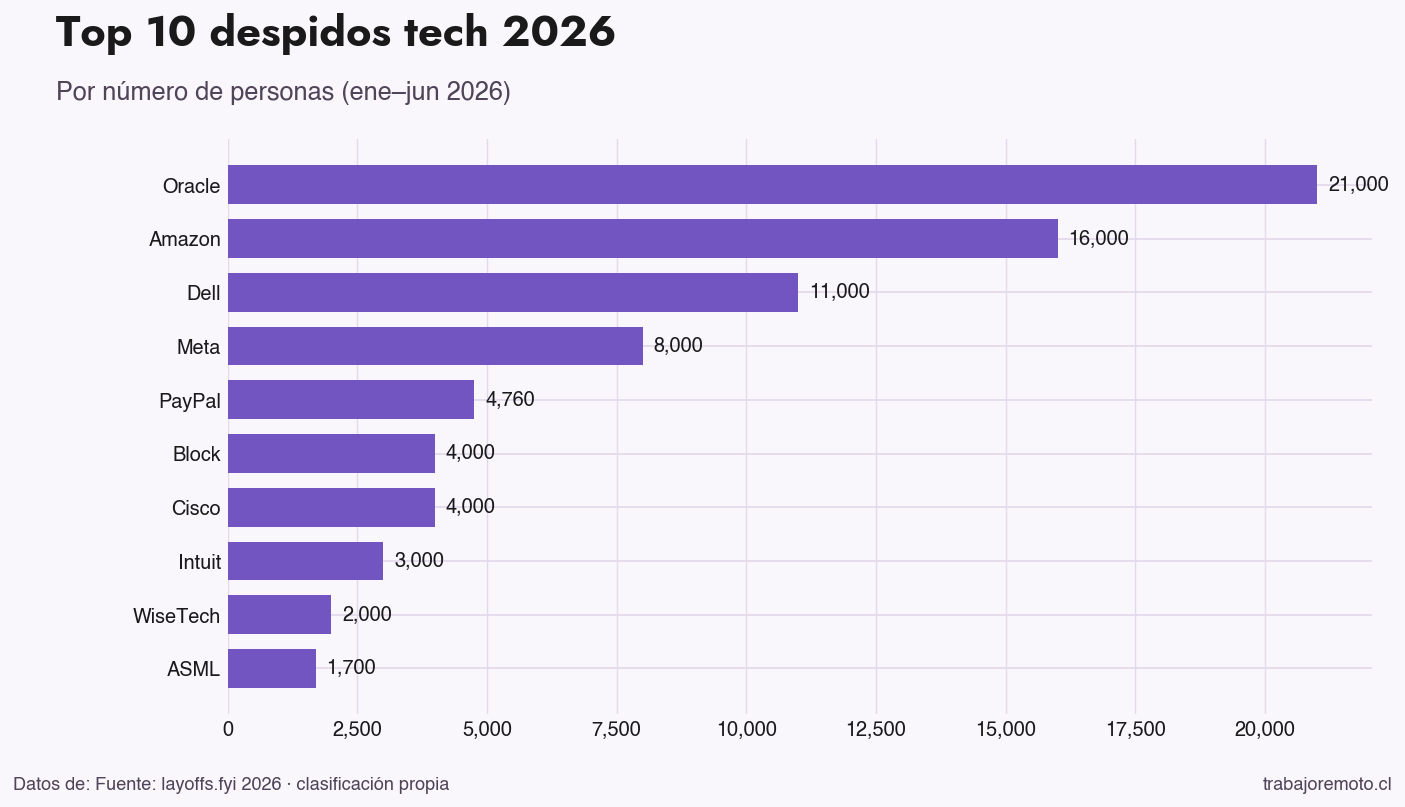

In [3]:
top = df.dropna(subset=['laid_off']).nlargest(10, 'laid_off').iloc[::-1]

fig, ax = new_chart(figsize=(11, 6.5))
ax.barh(top['company'], top['laid_off'], color=C['accent'], zorder=3, height=0.72)
ax.xaxis.set_major_formatter(FuncFormatter(fmt_int))
ax.grid(axis='x', color=C['grid'], zorder=1)
mx = top['laid_off'].max()
for y, v in enumerate(top['laid_off']):
    ax.text(v + mx*0.01, y, f"{int(v):,}", va='center', fontsize=11,
            color=C['title'], fontweight='600')

add_lenny_header(fig, title="Top 10 despidos tech 2026",
                 subtitle="Por número de personas (ene–jun 2026)")
source(fig, "Fuente: layoffs.fyi 2026 · clasificación propia")  # limpio, sin el footer con logo
plt.subplots_adjust(top=0.80, bottom=0.12, left=0.17, right=0.97)
plt.show()

---
## Análisis de datos

Columnas derivadas (misma lógica que el post y el panorama): la **razón real** (`bucket`), el
**veredicto** "¿fue por la IA?" (`verdict`), y si fue **auditada** contra la SEC (`auditada`).

In [4]:
# --- columnas derivadas ---
_audited_true = {"Amazon"}
def bucket_of(r):
    pos, rp, al, ho = r['ai_position'], r['reason_primary'], r['ai_link'], r['hire_overcorrection']
    if ho is True or r['company'] in _audited_true:        return 'sobre-contratación'
    if al == 'capex_funding':                              return 'invirtió en IA (declarado)'
    if rp == 'new_ceo_turnaround':                         return 'CEO nuevo'
    if rp in ('shutdown_bankruptcy','m_and_a_consolidation','ipo_prep'): return 'compra/fusión/cierre'
    if pos == 'n/a' or rp in ('demand_collapse','lost_contract_market_exit'): return 'caída de demanda'
    if rp in ('cost_cutting','restructuring_vague','ai_substitution_claim','strategic_pivot','ai_capex_reallocation'): return 'recorte de costos'
    return 'otro'

def verdict_of(r):
    b, link, ho, si = r['ai_link_basis'], r['ai_link'], r['hire_overcorrection'], r['story_integrity']
    if b == 'company_denied':        return 'La empresa niega que fue por la IA'
    if link == 'unrelated':          return 'Sin relación con la IA'
    if b == 'press_inferred':        return 'La prensa dice que fue culpa de la IA (sin verificar)'
    if b == 'company_informal':      return 'La empresa culpa a la IA (sin verificar)'
    if link == 'capex_funding':      return 'Recortaron para invertir en la IA'
    if link == 'direct_substitution':
        return 'Sí, la IA reemplazó' if (si == 'holds' and ho is not True) else 'Culparon a la IA, pero no cuadra'
    if link == 'ai_narrative_only':  return 'Culparon a la IA, pero no cuadra'
    return 'Sin relación con la IA'

def audit_label(v):
    if v is True:  return 'sobre-contrató'
    if v is False: return 'no sobre-contrató'
    return 'sin auditar'

df['bucket']   = df.apply(bucket_of, axis=1)
df['verdict']  = df.apply(verdict_of, axis=1)
df['auditada'] = df['hire_overcorrection'].apply(audit_label)
df[['company','laid_off','ai_link','bucket','verdict','auditada']].head()

,company,laid_off,ai_link,bucket,verdict,auditada
0,Multiverse,55.0,unrelated,caída de demanda,Sin relación con la IA,sin auditar
1,Angi,350.0,direct_substitution,recorte de costos,La empresa culpa a la IA (sin verificar),sin auditar
2,Foretellix,29.0,ai_narrative_only,recorte de costos,La prensa dice que fue culpa de la IA (sin ver...,sin auditar
3,Hailo,30.0,ai_narrative_only,recorte de costos,La empresa culpa a la IA (sin verificar),sin auditar
4,Kaseya,250.0,unrelated,caída de demanda,Sin relación con la IA,sin auditar


### Empresas y personas por razón de fondo

Clasificando cada empresa por su factor **dominante** (una sola por empresa; ojo con esta lectura, ver más abajo).

In [5]:
by_reason = (df.groupby('bucket')
               .agg(eventos=('company','size'),
                    empresas=('company','nunique'),
                    personas=('laid_off','sum'))
               .sort_values('personas', ascending=False))
by_reason['%'] = (100*by_reason['personas']/df['laid_off'].sum()).round(1)
by_reason

,eventos,empresas,personas,%
bucket,,,,
sobre-contratación,25,21,44060.0,40.8
recorte de costos,51,50,42846.0,39.6
caída de demanda,54,53,9462.0,8.8
CEO nuevo,4,4,6635.0,6.1
invirtió en IA (declarado),1,1,4000.0,3.7
compra/fusión/cierre,19,19,973.0,0.9
otro,7,7,113.0,0.1


En cambio, si a cada empresa la ponemos en la **combinación única** de factores que tiene (su intersección), las barras vuelven a sumar 100% y se ve cómo se mezclan las causas. En morado las combinaciones que incluyen un claim de IA:

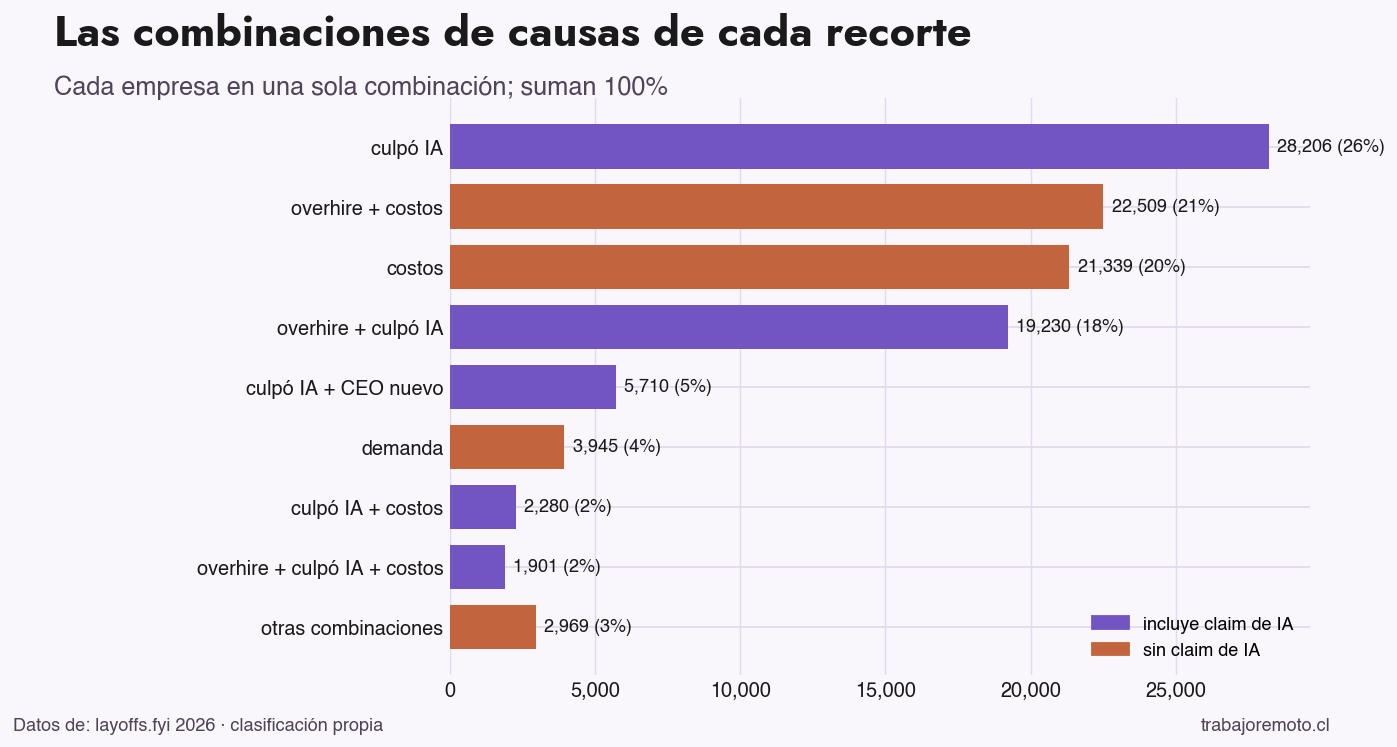

In [6]:
# combinaciones únicas de causas — cada empresa en una sola (suman 100%)
sub_costos=['cost_cutting','restructuring_vague','strategic_pivot']
sub_dem=['demand_collapse','lost_contract_market_exit']; sub_ma=['m_and_a_consolidation','shutdown_bankruptcy','ipo_prep']
F = {
  'overhire':   df['hire_overcorrection'] == True,
  'culpó IA':      df['ai_link'].isin(['direct_substitution','capex_funding','ai_narrative_only']) & df['ai_link_basis'].isin(['company_stated','company_informal']),
  'costos':        df['reason_primary'].isin(sub_costos),
  'demanda':       df['reason_primary'].isin(sub_dem),
  'CEO nuevo':     df['reason_primary'] == 'new_ceo_turnaround',
  'fusión/cierre': df['reason_primary'].isin(sub_ma),
}
FM = pd.DataFrame(F)
df['combo'] = FM.apply(lambda r: ' + '.join([k for k in F if r[k]]) or 'otro', axis=1)
tot = df['laid_off'].sum()
g = df.groupby('combo').agg(personas=('laid_off','sum'))
g['%'] = 100*g['personas']/tot
big = g[g['%'] >= 1.5].sort_values('personas')
otras = g[g['%'] < 1.5]['personas'].sum()
if otras > 0:
    big = pd.concat([pd.DataFrame({'personas':[otras],'%':[100*otras/tot]}, index=['otras combinaciones']), big])

import matplotlib.patches as mpatches
fig, ax = new_chart(figsize=(10.5, 6))
cols = [C['accent'] if 'culpó IA' in i else C['ser_muted'] for i in big.index]
ax.barh(big.index, big['personas'], color=cols, zorder=3, height=0.74)
ax.xaxis.set_major_formatter(FuncFormatter(fmt_int)); ax.grid(axis='x', color=C['grid'], zorder=1)
mx = big['personas'].max()
for y,(v,p) in enumerate(zip(big['personas'], big['%'])):
    ax.text(v + mx*0.01, y, f"{int(v):,} ({p:.0f}%)", va='center', fontsize=10, color=C['title'])
ax.legend(handles=[mpatches.Patch(color=C['accent'],    label='incluye claim de IA'),
                   mpatches.Patch(color=C['ser_muted'], label='sin claim de IA')],
          frameon=False, fontsize=10, loc='lower right')
add_lenny_header(fig, "Las combinaciones de causas de cada recorte",
                 "Cada empresa en una sola combinación; suman 100%")
source(fig, "layoffs.fyi 2026 · clasificación propia")
plt.subplots_adjust(top=0.84, bottom=0.10, left=0.34, right=0.97); plt.show()

### Sobre-contratación vs sus razones

¿Cuántas se pudieron auditar, y de las que sobre-contrataron, qué le dijeron al público?

In [7]:
print(df['auditada'].value_counts().to_string(), "\n")

# de las auditadas: sobre-contratación × lo que declararon (mecanismo de IA)
aud = df[df['auditada'] != 'sin auditar']
pd.crosstab(aud['auditada'], aud['ai_link'], margins=True, margins_name='total')

auditada
sin auditar          131
sobre-contrató        24
no sobre-contrató      6 



ai_link,ai_narrative_only,capex_funding,direct_substitution,unrelated,total
auditada,,,,,
no sobre-contrató,0,1,5,0,6
sobre-contrató,5,5,10,4,24
total,5,6,15,4,30


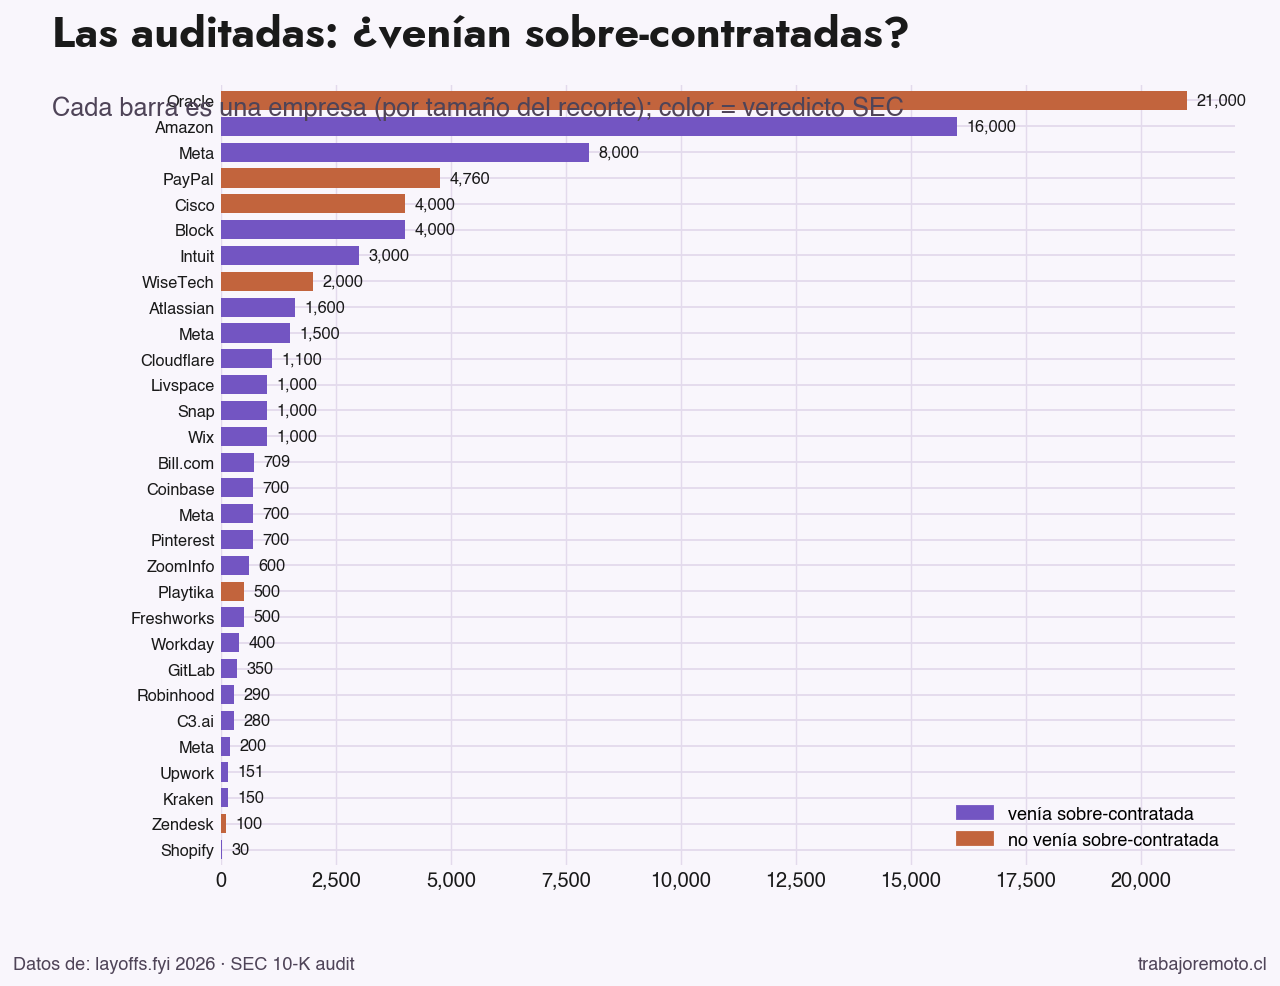

In [8]:
# viz: las empresas auditadas, ¿venían sobre-contratadas?
import matplotlib.patches as mpatches
a = (df[df['auditada'] != 'sin auditar']
       .dropna(subset=['laid_off']).sort_values('laid_off').reset_index(drop=True))
y = np.arange(len(a))
cmap = {'sobre-contrató': C['accent'], 'no sobre-contrató': C['ser_muted']}
fig, ax = new_chart(figsize=(10, 8))
ax.barh(y, a['laid_off'], color=a['auditada'].map(cmap), zorder=3, height=0.74)
ax.set_yticks(y); ax.set_yticklabels(a['company'], fontsize=9)
ax.set_ylim(-0.6, len(a)-0.4)
ax.xaxis.set_major_formatter(FuncFormatter(fmt_int)); ax.grid(axis='x', color=C['grid'], zorder=1)
mx = a['laid_off'].max()
for yi, v in zip(y, a['laid_off']):
    ax.text(v + mx*0.01, yi, f"{int(v):,}", va='center', fontsize=9, color=C['title'])
ax.legend(handles=[mpatches.Patch(color=C['accent'],    label='venía sobre-contratada'),
                   mpatches.Patch(color=C['ser_muted'], label='no venía sobre-contratada')],
          frameon=False, fontsize=10, loc='lower right')
add_lenny_header(fig, "Las auditadas: ¿venían sobre-contratadas?",
                 "Cada barra es una empresa (por tamaño del recorte); color = veredicto SEC")
source(fig, "layoffs.fyi 2026 · SEC 10-K audit")
plt.subplots_adjust(top=0.88, bottom=0.13, left=0.18, right=0.96); plt.show()

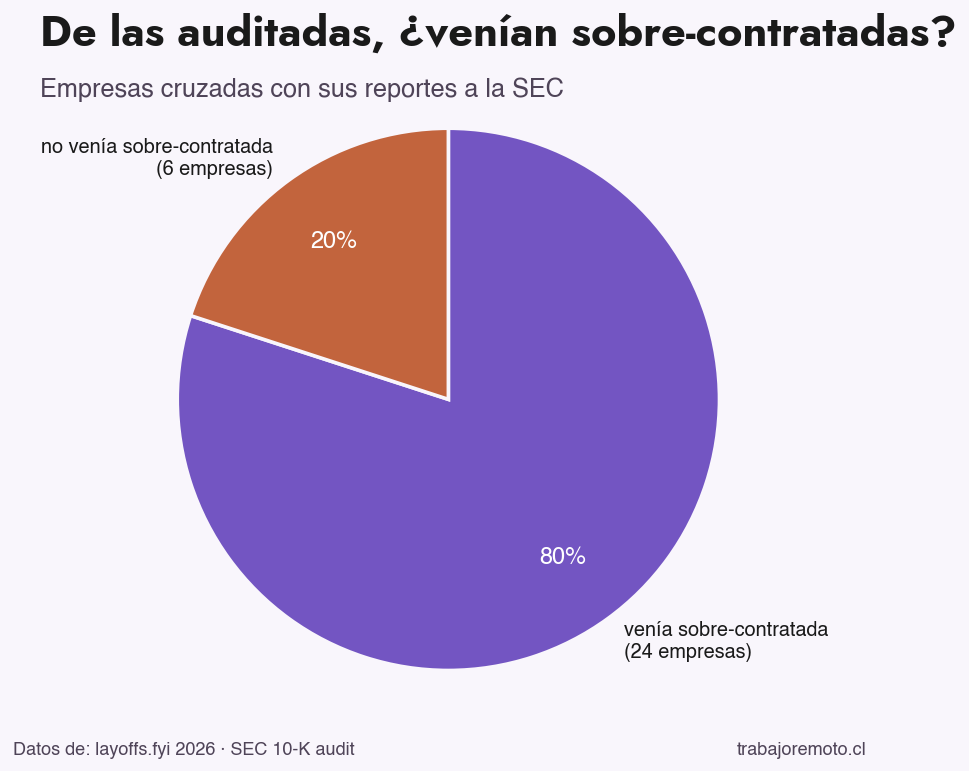

In [9]:
# viz: pie — de las auditadas, ¿sobre-contratadas?
counts = aud['auditada'].value_counts().reindex(['sobre-contrató','no sobre-contrató'])
labels = [f"venía sobre-contratada\n({counts.iloc[0]} empresas)",
          f"no venía sobre-contratada\n({counts.iloc[1]} empresas)"]
fig, ax = new_chart(figsize=(6.8, 6.2))
ax.set_axis_off()
wedges, texts, autotexts = ax.pie(
    counts.values, labels=labels, colors=[C['accent'], C['ser_muted']],
    autopct='%1.0f%%', startangle=90, counterclock=False, pctdistance=0.72,
    textprops={'fontsize': 11, 'color': C['title']},
    wedgeprops={'edgecolor': LENNY['bg'], 'linewidth': 2})
for at in autotexts:
    at.set_color('white'); at.set_fontweight('700'); at.set_fontsize(13)
ax.axis('equal')
add_lenny_header(fig, "De las auditadas, ¿venían sobre-contratadas?",
                 "Empresas cruzadas con sus reportes a la SEC")
source(fig, "layoffs.fyi 2026 · SEC 10-K audit")
plt.subplots_adjust(top=0.84, bottom=0.10); plt.show()

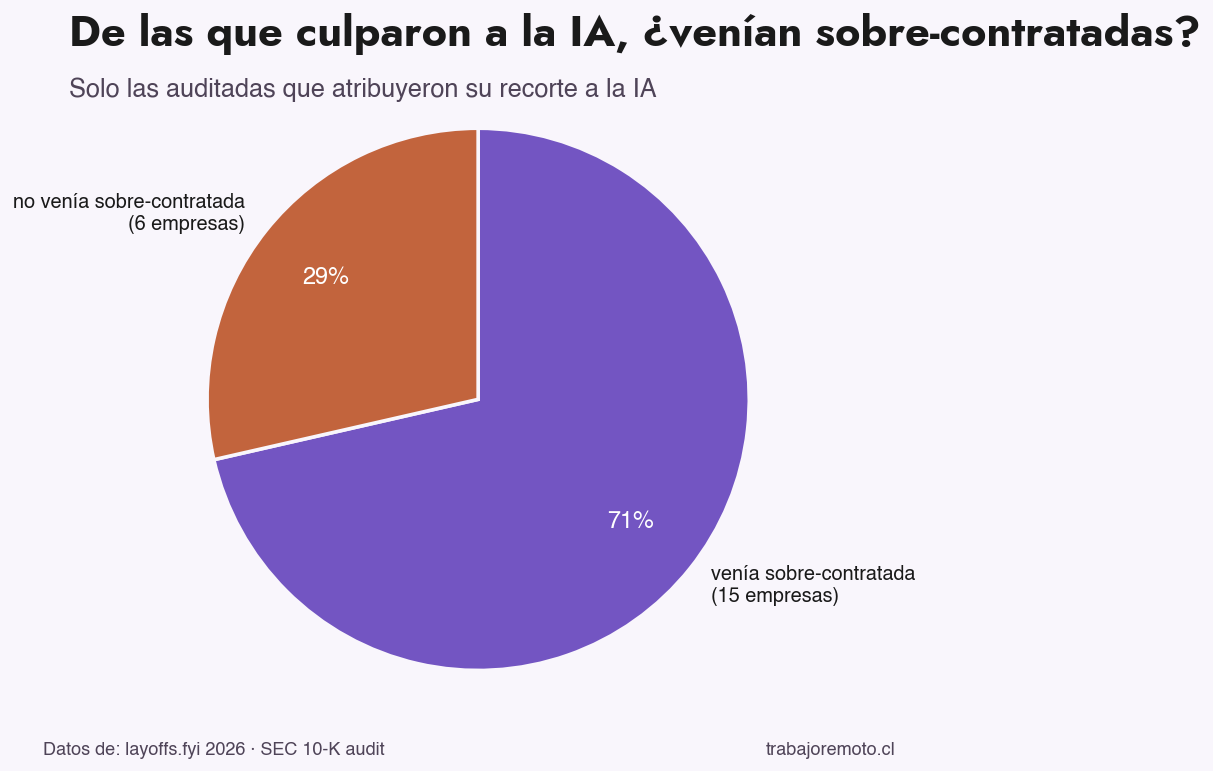

In [10]:
# viz: pie — de las auditadas QUE CULPARON A LA IA, ¿sobre-contratadas?
culpo_ia = ['Sí, la IA reemplazó','Culparon a la IA, pero no cuadra',
            'Recortaron para invertir en la IA','La empresa culpa a la IA (sin verificar)']
aud_ia = aud[aud['verdict'].isin(culpo_ia)]
counts = aud_ia['auditada'].value_counts().reindex(['sobre-contrató','no sobre-contrató']).fillna(0).astype(int)
labels = [f"venía sobre-contratada\n({counts.iloc[0]} empresas)",
          f"no venía sobre-contratada\n({counts.iloc[1]} empresas)"]
fig, ax = new_chart(figsize=(6.8, 6.2))
ax.set_axis_off()
wedges, texts, autotexts = ax.pie(
    counts.values, labels=labels, colors=[C['accent'], C['ser_muted']],
    autopct='%1.0f%%', startangle=90, counterclock=False, pctdistance=0.72,
    textprops={'fontsize': 11, 'color': C['title']},
    wedgeprops={'edgecolor': LENNY['bg'], 'linewidth': 2})
for at in autotexts:
    at.set_color('white'); at.set_fontweight('700'); at.set_fontsize(13)
ax.axis('equal')
add_lenny_header(fig, "De las que culparon a la IA, ¿venían sobre-contratadas?",
                 "Solo las auditadas que atribuyeron su recorte a la IA")
source(fig, "layoffs.fyi 2026 · SEC 10-K audit")
plt.subplots_adjust(top=0.84, bottom=0.10); plt.show()

### Las auditadas, una por una

In [11]:
cols = ['company','laid_off','ai_link','ai_link_basis','story_integrity','bucket','auditada']
(df[df['auditada'] != 'sin auditar'][cols]
   .sort_values('laid_off', ascending=False, na_position='last')
   .reset_index(drop=True))

,company,laid_off,ai_link,ai_link_basis,story_integrity,bucket,auditada
0,Oracle,21000.0,direct_substitution,company_stated,cracked,recorte de costos,no sobre-contrató
1,Amazon,16000.0,ai_narrative_only,company_denied,None,sobre-contratación,sobre-contrató
2,Meta,8000.0,capex_funding,company_stated,holds,sobre-contratación,sobre-contrató
3,PayPal,4760.0,direct_substitution,company_stated,cracked,CEO nuevo,no sobre-contrató
4,Block,4000.0,direct_substitution,company_stated,cracked,sobre-contratación,sobre-contrató
5,Cisco,4000.0,capex_funding,company_stated,holds,invirtió en IA (declarado),no sobre-contrató
6,Intuit,3000.0,ai_narrative_only,company_denied,None,sobre-contratación,sobre-contrató
7,WiseTech,2000.0,direct_substitution,company_stated,cracked,recorte de costos,no sobre-contrató
8,Atlassian,1600.0,capex_funding,company_stated,cracked,sobre-contratación,sobre-contrató
9,Meta,1500.0,unrelated,company_stated,None,sobre-contratación,sobre-contrató


### De las que culparon a la IA, ¿qué dice la evidencia?

Tomamos solo las que atribuyeron el recorte a la IA y vemos qué muestran sus números. Casi todo se explica por otra cosa; la IA verificada es un sliver.

In [12]:
si = df[df['story_integrity'].notna()]
print(si['story_integrity'].value_counts().to_string(), "\n")
pd.crosstab(si['ai_link_basis'], si['story_integrity'], margins=True, margins_name='total')

story_integrity
cracked    16
holds       6
busted      4
unknown     1 



story_integrity,busted,cracked,holds,unknown,total
ai_link_basis,,,,,
company_stated,3,16,6,0,25
press_inferred,1,0,0,0,1
unknown,0,0,0,1,1
total,4,16,6,1,27


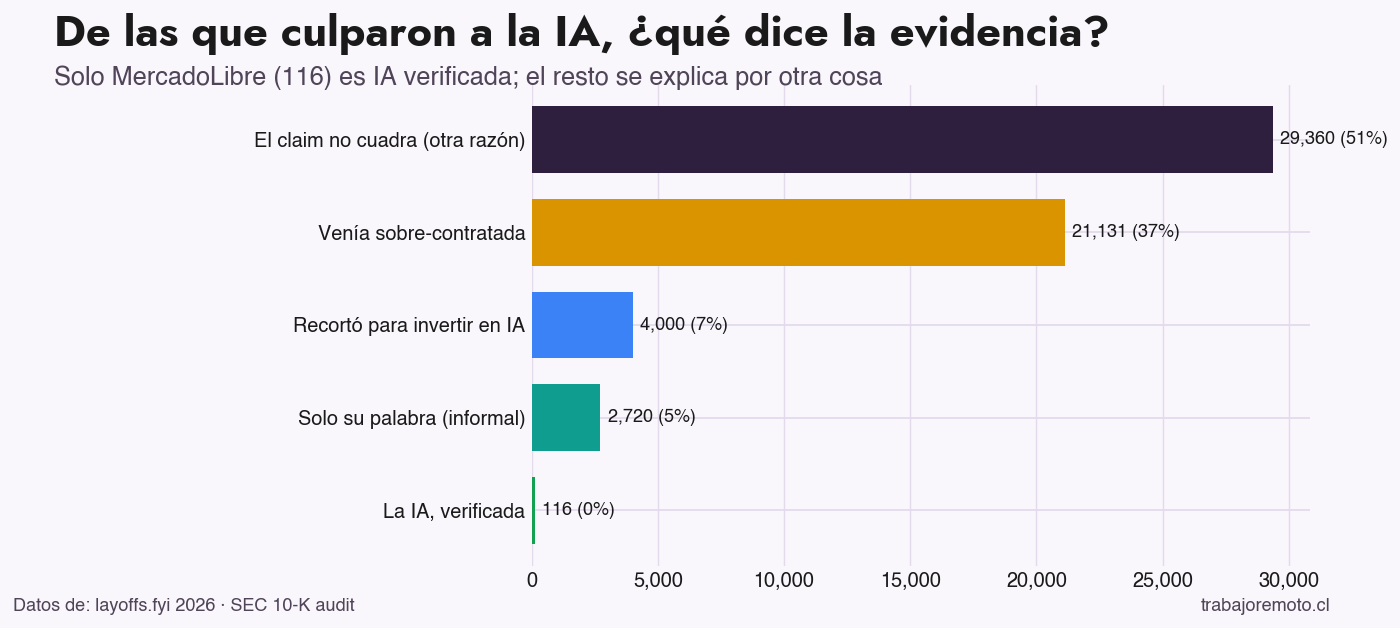

In [13]:
# de las que culparon a la IA, ¿qué dice la evidencia? (cruzando con la razón real)
mask_ia = (df['ai_link'].isin(['direct_substitution','capex_funding','ai_narrative_only'])
           & df['ai_link_basis'].isin(['company_stated','company_informal']))
def real_story(r):
    if r['hire_overcorrection'] is True:                                          return 'Venía sobre-contratada'
    if r['ai_link'] == 'capex_funding':                                           return 'Recortó para invertir en IA'
    if r['story_integrity'] == 'holds' and r['ai_link'] == 'direct_substitution': return 'La IA, verificada'
    if r['ai_link_basis'] == 'company_informal':                                  return 'Solo su palabra (informal)'
    return 'El claim no cuadra (otra razón)'
ia = df[mask_ia].copy(); ia['real'] = ia.apply(real_story, axis=1)
tot = ia['laid_off'].sum()
ev = ia.groupby('real').agg(personas=('laid_off','sum'), empresas=('company','nunique'))
ev['%'] = 100*ev['personas']/tot
ev = ev.sort_values('personas')
col = {'La IA, verificada':'#12a150', 'Solo su palabra (informal)':'#0e9d8f',
       'Recortó para invertir en IA':'#3b82f6', 'Venía sobre-contratada':'#d99400',
       'El claim no cuadra (otra razón)':C['ser_secondary']}
fig, ax = new_chart(figsize=(10.5, 5))
ax.barh(ev.index, ev['personas'], color=[col.get(i, C['accent']) for i in ev.index], zorder=3, height=0.72)
ax.xaxis.set_major_formatter(FuncFormatter(fmt_int)); ax.grid(axis='x', color=C['grid'], zorder=1)
mx = ev['personas'].max()
for y,(v,p) in enumerate(zip(ev['personas'], ev['%'])):
    ax.text(v + mx*0.01, y, f"{int(v):,} ({p:.0f}%)", va='center', fontsize=10, color=C['title'])
add_lenny_header(fig, "De las que culparon a la IA, ¿qué dice la evidencia?",
                 "Solo MercadoLibre (116) es IA verificada; el resto se explica por otra cosa")
source(fig, "layoffs.fyi 2026 · SEC 10-K audit")
plt.subplots_adjust(top=0.84, bottom=0.10, left=0.40, right=0.97); plt.show()

### Empresas de cada razón

Qué empresas caen en cada bucket (razón real), ordenadas por tamaño del recorte.

In [14]:
from IPython.display import display, Markdown
for b in by_reason.index:  # buckets ordenados por nº de personas
    sub = (df[df['bucket'] == b][['company','laid_off','ai_link','verdict','auditada']]
             .sort_values('laid_off', ascending=False, na_position='last')
             .reset_index(drop=True))
    display(Markdown(f"#### {b} — {len(sub)} eventos · {int(sub['laid_off'].sum()):,} personas"))
    display(sub)

#### sobre-contratación — 25 eventos · 44,060 personas

,company,laid_off,ai_link,verdict,auditada
0,Amazon,16000.0,ai_narrative_only,La empresa niega que fue por la IA,sobre-contrató
1,Meta,8000.0,capex_funding,Recortaron para invertir en la IA,sobre-contrató
2,Block,4000.0,direct_substitution,"Culparon a la IA, pero no cuadra",sobre-contrató
3,Intuit,3000.0,ai_narrative_only,La empresa niega que fue por la IA,sobre-contrató
4,Atlassian,1600.0,capex_funding,Recortaron para invertir en la IA,sobre-contrató
5,Meta,1500.0,unrelated,Sin relación con la IA,sobre-contrató
6,Cloudflare,1100.0,ai_narrative_only,"Culparon a la IA, pero no cuadra",sobre-contrató
7,Wix,1000.0,direct_substitution,"Culparon a la IA, pero no cuadra",sobre-contrató
8,Livspace,1000.0,direct_substitution,"Culparon a la IA, pero no cuadra",sobre-contrató
9,Snap,1000.0,direct_substitution,"Culparon a la IA, pero no cuadra",sobre-contrató


#### recorte de costos — 51 eventos · 42,846 personas

,company,laid_off,ai_link,verdict,auditada
0,Oracle,21000.0,direct_substitution,"Culparon a la IA, pero no cuadra",no sobre-contrató
1,Dell,11000.0,unrelated,Sin relación con la IA,sin auditar
2,WiseTech,2000.0,direct_substitution,"Culparon a la IA, pero no cuadra",no sobre-contrató
3,ASML,1700.0,unrelated,Sin relación con la IA,sin auditar
4,Autodesk,1000.0,ai_narrative_only,La empresa niega que fue por la IA,sin auditar
5,eBay,800.0,unrelated,Sin relación con la IA,sin auditar
6,Playtika,500.0,direct_substitution,"Culparon a la IA, pero no cuadra",no sobre-contrató
7,Flipkart,500.0,unrelated,Sin relación con la IA,sin auditar
8,Stone,400.0,ai_narrative_only,La empresa culpa a la IA (sin verificar),sin auditar
9,Angi,350.0,direct_substitution,La empresa culpa a la IA (sin verificar),sin auditar


#### caída de demanda — 54 eventos · 9,462 personas

...

,company,laid_off,ai_link,verdict,auditada
0,Cisco,4000.0,capex_funding,Recortaron para invertir en la IA,no sobre-contrató


#### compra/fusión/cierre — 19 eventos · 973 personas

,company,laid_off,ai_link,verdict,auditada
0,Cyberark,500.0,unrelated,Sin relación con la IA,sin auditar
1,Adda247,200.0,unrelated,Sin relación con la IA,sin auditar
2,Clari,76.0,ai_narrative_only,La prensa dice que fue culpa de la IA (sin ver...,sin auditar
3,Polygon,60.0,unrelated,Sin relación con la IA,sin auditar
4,Acko,60.0,ai_narrative_only,La prensa dice que fue culpa de la IA (sin ver...,sin auditar
5,Axonius,40.0,unrelated,Sin relación con la IA,sin auditar
6,Swyftx,37.0,unrelated,Sin relación con la IA,sin auditar
7,StoreDot,NaN,unrelated,Sin relación con la IA,sin auditar
8,Entropy,NaN,unrelated,Sin relación con la IA,sin auditar
9,Verint Systems,NaN,ai_narrative_only,La prensa dice que fue culpa de la IA (sin ver...,sin auditar


#### otro — 7 eventos · 113 personas

,company,laid_off,ai_link,verdict,auditada
0,Truecaller,70.0,unrelated,Sin relación con la IA,sin auditar
1,LSports,40.0,unrelated,Sin relación con la IA,sin auditar
2,Tailwind Labs,3.0,unrelated,Sin relación con la IA,sin auditar
3,Cars.com,NaN,unrelated,Sin relación con la IA,sin auditar
4,Life360,NaN,unrelated,Sin relación con la IA,sin auditar
5,reAlpha,NaN,unrelated,Sin relación con la IA,sin auditar
6,MessageBird,NaN,unrelated,Sin relación con la IA,sin auditar


### Veredicto "¿fue por la IA?" (como en la tabla del panorama)

> Reconstruido desde los campos crudos; puede diferir en ±1 evento de la tabla del panorama, que usa la clasificación adjudicada de `categorize.py`. Para el conteo oficial, manda la tabla.

In [15]:
(df.groupby('verdict')
   .agg(eventos=('company','size'), empresas=('company','nunique'), personas=('laid_off','sum'))
   .sort_values('personas', ascending=False))

,eventos,empresas,personas
verdict,,,
"Culparon a la IA, pero no cuadra",19,19,39341.0
Sin relación con la IA,93,92,28717.0
La empresa niega que fue por la IA,3,3,20000.0
Recortaron para invertir en la IA,6,6,15250.0
La empresa culpa a la IA (sin verificar),23,23,2720.0
La prensa dice que fue culpa de la IA (sin verificar),16,15,1945.0
"Sí, la IA reemplazó",1,1,116.0


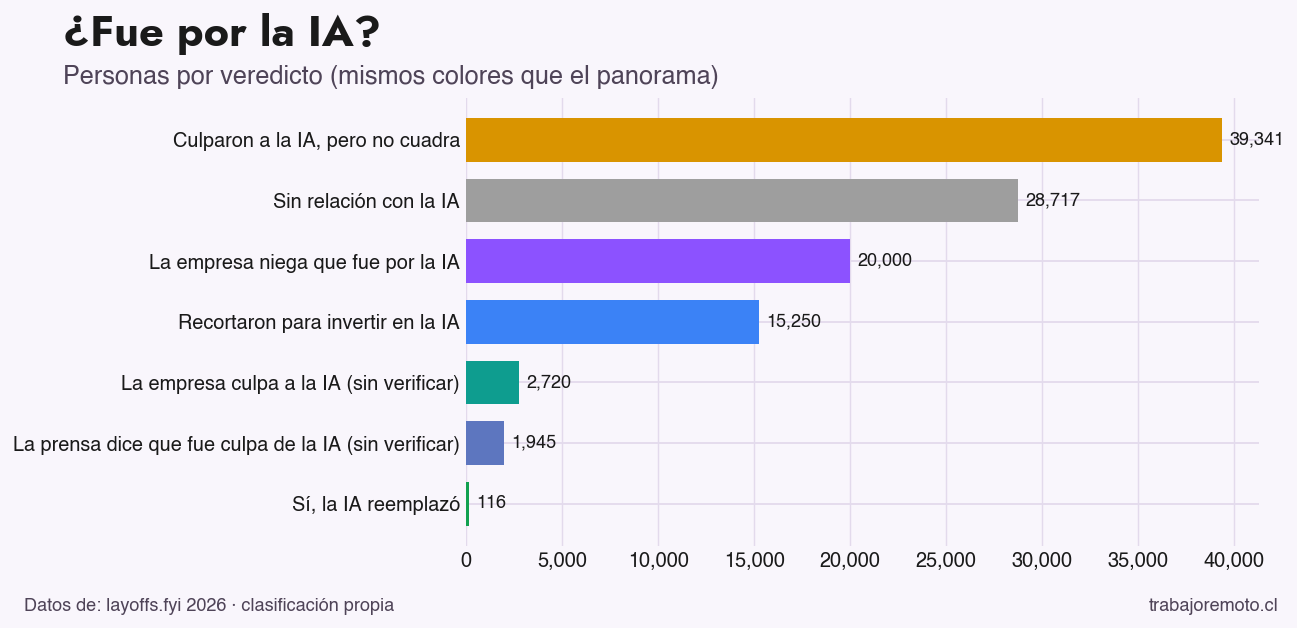

In [16]:
# viz: veredicto (mismos colores que el panorama)
v = df.groupby('verdict')['laid_off'].sum().sort_values()
vcol = {'Sí, la IA reemplazó':'#12a150','La empresa culpa a la IA (sin verificar)':'#0e9d8f',
        'Culparon a la IA, pero no cuadra':'#d99400','Recortaron para invertir en la IA':'#3b82f6',
        'La prensa dice que fue culpa de la IA (sin verificar)':'#5d76bf','La empresa niega que fue por la IA':'#8c52ff','Sin relación con la IA':'#9e9e9e'}
fig, ax = new_chart(figsize=(10, 5))
ax.barh(v.index, v.values, color=[vcol.get(k, C['accent']) for k in v.index], zorder=3, height=0.72)
ax.xaxis.set_major_formatter(FuncFormatter(fmt_int)); ax.grid(axis='x', color=C['grid'], zorder=1)
mx = v.max()
for y,val in enumerate(v.values):
    ax.text(val+mx*0.01, y, f"{int(val):,}", va='center', fontsize=10, color=C['title'])
add_lenny_header(fig, "¿Fue por la IA?", "Personas por veredicto (mismos colores que el panorama)")
source(fig, "layoffs.fyi 2026 · clasificación propia")
plt.subplots_adjust(top=0.82, bottom=0.13, left=0.36, right=0.97); plt.show()

### Las que negaron la IA — ¿alguna negación no cuadra?

Son 3. Ninguna es una mentira clara: las que **sobre-contrataron** (Amazon, Intuit) tienen una razón real distinta a la IA, así que negarla *cuadra*. El matiz: **Intuit y Autodesk niegan que la IA causara el despido, pero a la vez reasignan plata hacia la IA**.

In [17]:
den = df[df['verdict'] == 'La empresa niega que fue por la IA']
display(den[['company','laid_off','auditada','ai_position','bucket']].reset_index(drop=True))
for _, r in den.sort_values('laid_off', ascending=False).iterrows():
    print(f"\n{r['company']} ({r['laid_off']}) · {r['auditada']}")
    print("  ", (r.get('reason') or '')[:230])

,company,laid_off,auditada,ai_position,bucket
0,Autodesk,1000.0,sin auditar,token_buyer,recorte de costos
1,Amazon,16000.0,sobre-contrató,hybrid,sobre-contratación
2,Intuit,3000.0,sobre-contrató,token_buyer,sobre-contratación



Amazon (16000.0) · sobre-contrató
   Amazon is strengthening its organization by reducing layers, increasing ownership, and removing bureaucracy across corporate roles. The memo (Beth Galetti, SVP PXT) contains no mention of AI; an Amazon spokesperson told AP (~Feb 1

Intuit (3000.0) · sobre-contrató
   CEO Sasan Goodarzi internal memo: cuts (17% of ~18,200 employees) framed as 'reducing complexity and simplifying the corporate structure' to deliver better products and consolidate teams in key hubs (winding down Reno and Woodland

Autodesk (1000.0) · sin auditar
   CEO Andrew Anagnost framed the ~7% cut (mostly customer-facing sales) as completion of a multi-year go-to-market transformation, with smaller targeted adjustments to align with future opportunities. Resources reallocated to AI, pl


### Otras dimensiones (país, industria, etapa)

In [18]:
for col in ['country','industry','stage']:
    t = (df.groupby(col).agg(eventos=('company','size'), personas=('laid_off','sum'))
           .sort_values('personas', ascending=False).head(8))
    print(f"— por {col} —"); print(t.to_string(), "\n")

— por country —
                eventos  personas
country                          
United States        88   90301.0
Australia             4    3837.0
Israel               19    3041.0
India                11    2155.0
Sweden                4    1835.0
Netherlands           2    1700.0
United Kingdom        5    1382.0
Kenya                 1    1108.0 

— por industry —
                eventos  personas
industry                         
Other                13   25926.0
Retail               11   18011.0
Consumer             28   16654.0
Finance              22   13856.0
Hardware              4   12950.0
Infrastructure        1    4000.0
Security             10    2314.0
Logistics             1    2000.0 

— por stage —
                eventos  personas
stage                            
Post-IPO             67   94873.0
Acquired             20    3369.0
Unknown              23    3352.0
Series B              7    1628.0
Private Equity        6    1604.0
Series F              6    1260

## Guardar para el blog

`save_chart(fig, "mi-grafico")` deja el PNG en `charts/`. Para publicarlo en el blog, cópialo a
`../trabajo/images/2026-06-17-<nombre>.png` (o el nombre que uses en el post).

In [19]:
# save_chart(fig, "mi-grafico")   # descomenta para guardar el último fig

---
## Análisis exploratorio (multi-causa)

Con los tags `causes` (una lista por evento), podemos ver cómo se mezclan las causas y si los despidos se agrupan solos en arquetipos.

In [20]:
# one-hot de los tags de causa
all_tags = sorted({t for cs in df['causes'] for t in cs})
T = pd.DataFrame({t: df['causes'].apply(lambda cs: t in cs) for t in all_tags}, index=df.index)
print(len(all_tags), "tags ·", int(df['causes'].apply(len).mean()*100)/100, "promedio por evento")
T.sum().sort_values(ascending=False).head(12)

21 tags · 1.71 promedio por evento


restructuring_unspecified    56
cost_cutting                 44
ai_substitution_claim        27
over_hiring                  24
ai_framing_vague             16
ai_press_narrative           16
m_and_a                      12
financial_distress           10
strategic_pivot              10
unknown                       9
shutdown                      9
demand_collapse               7
dtype: int64

### Co-ocurrencia de causas

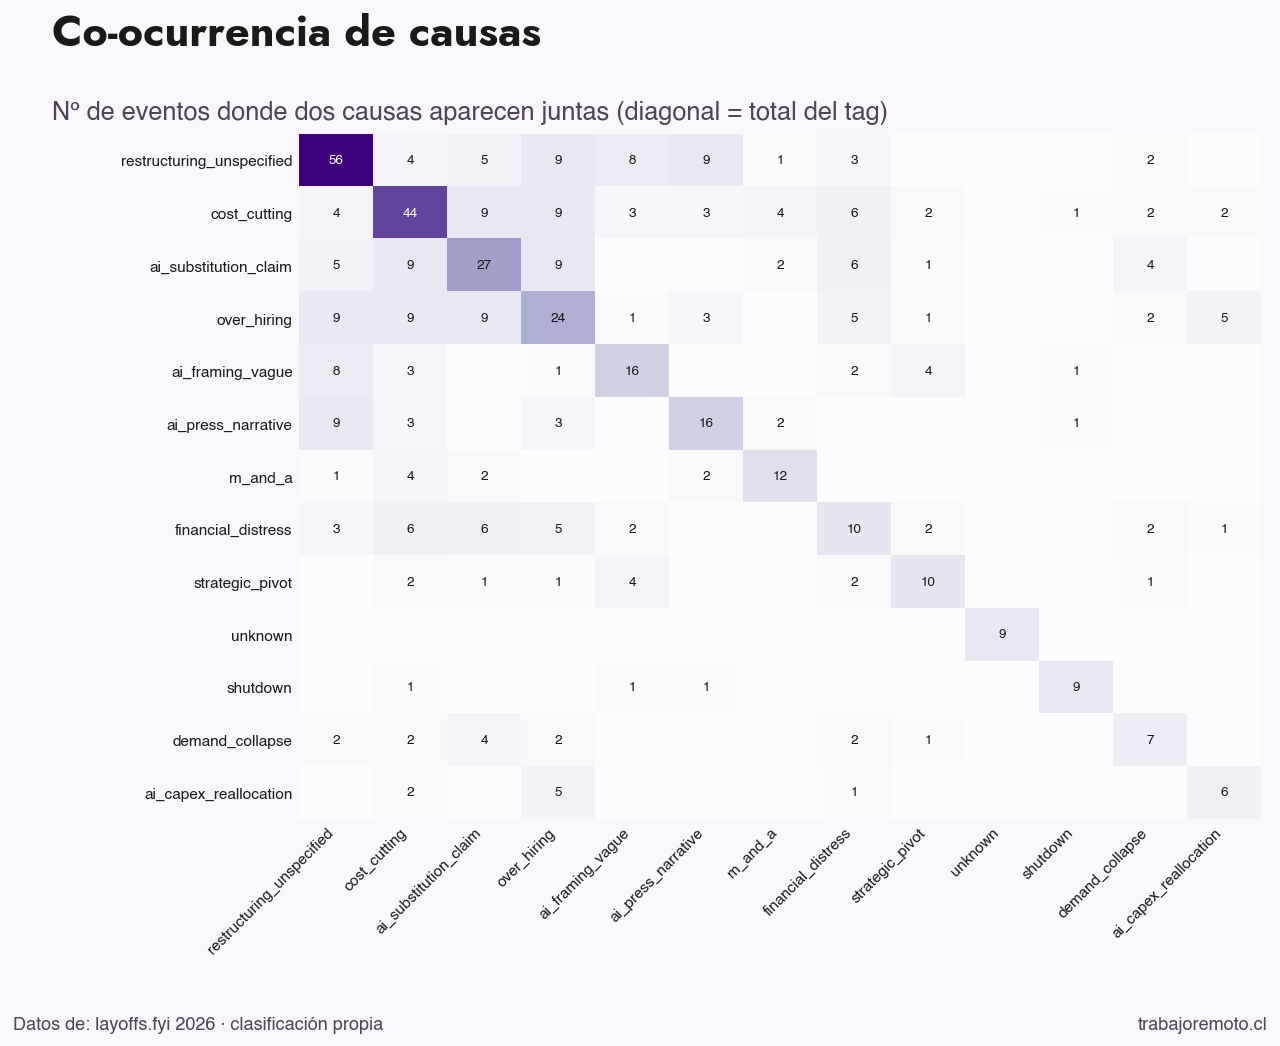

In [21]:
M = (T.astype(int).T @ T.astype(int))
freq = pd.Series({t: M.loc[t,t] for t in all_tags}).sort_values(ascending=False)
top = freq.head(13).index.tolist()
Mo = M.loc[top, top]
fig, ax = new_chart(figsize=(10, 8.5)); ax.grid(False)
im = ax.imshow(Mo.values, cmap="Purples", aspect="auto")
ax.set_xticks(range(len(top))); ax.set_xticklabels(top, rotation=45, ha="right", fontsize=8.5)
ax.set_yticks(range(len(top))); ax.set_yticklabels(top, fontsize=8.5)
vmax = Mo.values.max()
for i in range(len(top)):
    for j in range(len(top)):
        v = Mo.values[i, j]
        if v: ax.text(j, i, int(v), ha="center", va="center", fontsize=7.5,
                      color="white" if v > vmax*0.5 else C["title"])
add_lenny_header(fig, "Co-ocurrencia de causas", "Nº de eventos donde dos causas aparecen juntas (diagonal = total del tag)")
source(fig, "layoffs.fyi 2026 · clasificación propia")
plt.subplots_adjust(top=0.84, bottom=0.22, left=0.24, right=0.98); plt.show()

### ¿Con qué se mezcla el claim de "la IA nos reemplazó"?

*Lift* = cuántas veces más probable que aparezca cada causa **dado que** la empresa culpó a la IA, versus su frecuencia base. >1 (morado) = se mezcla más que al azar.

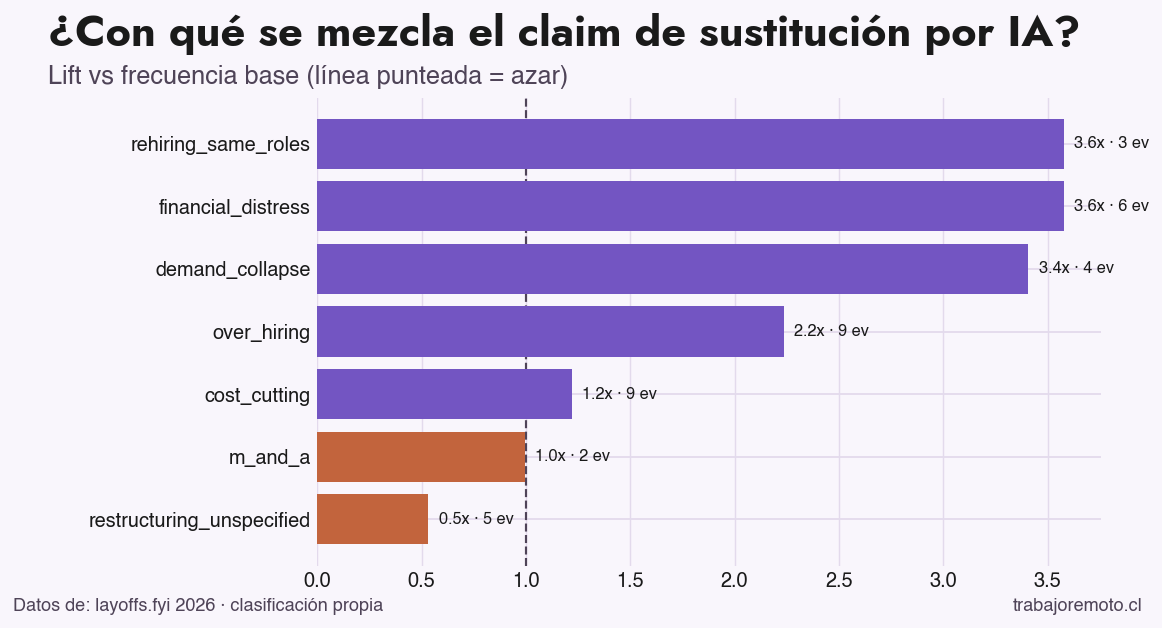

In [22]:
claim_mask = df['causes'].apply(lambda cs: 'ai_substitution_claim' in cs)
sub  = T[claim_mask]
co   = sub.sum().drop('ai_substitution_claim')
base = T.mean().drop('ai_substitution_claim')
lift = (sub.mean().drop('ai_substitution_claim') / base)
keep = co[co >= 2].index
lift = lift[keep].sort_values()
fig, ax = new_chart(figsize=(9, 5))
ax.barh(lift.index, lift.values, color=[C['accent'] if v>=1 else C['ser_muted'] for v in lift.values], zorder=3)
ax.axvline(1, color=C['subtitle'], lw=1.2, ls='--', zorder=2)
ax.grid(axis='x', color=C['grid'], zorder=1)
for y,(v,n) in enumerate(zip(lift.values, co[keep].reindex(lift.index).values)):
    ax.text(v+0.05, y, f"{v:.1f}x · {int(n)} ev", va='center', fontsize=9, color=C['title'])
add_lenny_header(fig, "¿Con qué se mezcla el claim de sustitución por IA?", "Lift vs frecuencia base (línea punteada = azar)")
source(fig, "layoffs.fyi 2026 · clasificación propia")
plt.subplots_adjust(top=0.82, bottom=0.10, left=0.28, right=0.95); plt.show()

### Arquetipos (clustering no supervisado)

Clustering jerárquico (distancia Jaccard). Con n=161 y tags binarios, lo esperable pasa: casi todo colapsa en **un arquetipo grande de "reestructuración/costos genéricos"**, y solo se separan los grupos raros (IPO prep, cierres, regulatorio). **La estructura real está en la co-ocurrencia y el lift de arriba, no en el clustering** — n es muy chico para que encuentre sub-grupos finos.

In [23]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist
X = T[all_tags].astype(int).values
Z = linkage(pdist(X, metric='jaccard'), method='average')
df['cluster'] = fcluster(Z, t=6, criterion='maxclust')
for c in sorted(df['cluster'].unique()):
    m = df['cluster'] == c
    dom = T[m][all_tags].mean().sort_values(ascending=False)
    dom = dom[dom >= 0.4]
    print(f"Arquetipo {c}: {int(m.sum())} eventos · {int(df.loc[m,'laid_off'].sum()):,} personas")
    print(f"  perfil: {', '.join(f'{k} ({v:.0%})' for k,v in dom.items())}")
    print(f"  ejemplos: {', '.join(df.loc[m].nlargest(3,'laid_off')['company'])}\n")

Arquetipo 1: 3 eventos · 240 personas
  perfil: ipo_prep (100%)
  ejemplos: Adda247, Axonius, StoreDot

Arquetipo 2: 3 eventos · 1,345 personas
  perfil: market_exit (100%)
  ejemplos: Sama, Deliveroo, Monzo

Arquetipo 3: 125 eventos · 103,715 personas
  perfil: restructuring_unspecified (45%)
  ejemplos: Oracle, Amazon, Dell

Arquetipo 4: 20 eventos · 2,456 personas
  perfil: shutdown (40%)
  ejemplos: UKG, LinkedIn, Bungie

Arquetipo 5: 9 eventos · 133 personas
  perfil: unknown (100%)
  ejemplos: Truecaller, LSports, Guesty

Arquetipo 6: 1 eventos · 200 personas
  perfil: regulatory (100%)
  ejemplos: Zupee



## Tips

- Para **replicar un gráfico publicado**, mira su función en `charts.py` (ej. `chart_real_buckets`,
  `chart_ai_position`, `chart_ai_claim_vs_overhire`) y copia el cuerpo a una celda para iterarlo.
- Llamar `charts.chart_real_buckets(lang="es")` **regenera** ese PNG en `charts/` (no lo muestra inline).
- `charts.data` ya viene filtrada a ene–jun 2026 (`date < 2026-07-01`), igual que el post.
- El footer con logo (`add_footer_branding`) existe en `charts.py`, pero para iterar conviene la línea `source(fig, ...)` (más limpia).